# Notebook 11: Text-/Job Market-Based Skill Mining (TF-IDF/N-Grams), Methodology 2.1

Typical terms/skills are extracted from external text sources and mapped to a controlled skill vocabulary. The results are then aggregated by KldB occupation and compared with the existing target profile, which is being expanded.

The following notebook follows the steps of skill mining: term/phrase extraction from text (TF-IDF/N-grams), normalization and noise reduction, and mapping of candidates to a skill taxonomy using string similarity. ESCO and supplementary vocabularies/sources serve as skill references. Specific methodological references and literature are explained throughout the notebook in the respective sections. (Based on the literature (Boselli et al. (2018); Karakatsanis et al. (2017); Malherbe & Aufaure (2016); Mason et al. (2023); Pejic-Bach et al. (2020)).

Why Method 2.1:
- The market is the fastest source for new skills; it extracts current skill trends and is scalable
- Candidates are derived from the text (not just from a skill lexicon as in 1.1)

Distinction from Method 1.1:
- 1.1: Skill recognition via rule-based skill vocabulary matching in the text (lexicon/dictionary-driven).
- 2.1: Candidates are first generated data-driven from text (TF-IDF/N-grams); only then is mapping to skills performed.

Outputs (analogous to 10b):
1. Doc-level: `doc_id -> KldB match + term candidates + mapped skill_id`
2. Doc×Skill Long
3. Aggregation per KldB (`doc_freq`, `skill_count`)
4. Novel Skills vs. Target -> Extension List
5. Extended Target (Long & Agg)
6. Gold/Eval Export: `(doc_id, skill_id, method)` + Meta

(Alternative notebooks and files under: notebooks\11-Alternative\)

In [1]:
# Imports + Paths
from pathlib import Path
import re
import json
import numpy as np
import pandas as pd
from rapidfuzz import process, fuzz
from sklearn.feature_extraction.text import TfidfVectorizer

# Project Root
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_INTERIM = DATA_DIR / "interim"
DATA_PROCESSED = DATA_DIR / "processed"
DATA_PROCESSED_EXTERNAL = DATA_DIR / "processed_external"

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung


In [4]:
# Paths
DOCS_PATH = DATA_PROCESSED_EXTERNAL / "documents_raw.parquet"

KDB_MAPPING_PATH = DATA_INTERIM / "kldb_esco_mapping.parquet"
KDB_SOLL_LONG_PATH = DATA_PROCESSED / "kldb_skills_soll_long.parquet"
KDB_SOLL_AGG_PATH  = DATA_PROCESSED / "kldb_skills_soll_agg.parquet"

# Skill-Concepts (from 10A, filtered)
CONCEPTS_PATH_CANDIDATES = [
    DATA_PROCESSED_EXTERNAL / "skills_concepts_filtered.parquet",  # bevorzugt
    DATA_PROCESSED_EXTERNAL / "skills_concepts.parquet", # fallback
]

def load_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

CONCEPTS_PATH = load_first_existing(CONCEPTS_PATH_CANDIDATES)
print("CONCEPTS_PATH:", CONCEPTS_PATH)

# Output folder for 2.1 (separate folder; outputs from 1.1/10b are in the overall `processed_external` folder)
OUT_DIR = DATA_PROCESSED_EXTERNAL / "method_2_1"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Outputs
DOC_TERMS_PATH       = OUT_DIR / "doc_terms_2_1.parquet"
DOC_TERM_MAP_PATH    = OUT_DIR / "doc_term_map_2_1_long.parquet"
DOC_SKILLS_FULL_PATH = OUT_DIR / "doc_skills_2_1_full.parquet"
KDB_SKILLS_AGG_PATH  = OUT_DIR / "kldb_skills_2_1_agg.parquet"
KDB_EXT_PATH         = OUT_DIR / "kldb_skill_extension_2_1.parquet"
SOLL_LONG_EXT_PATH   = OUT_DIR / "kldb_skills_soll_long_extended_2_1.parquet"
SOLL_AGG_EXT_PATH    = OUT_DIR / "kldb_skills_soll_agg_extended_2_1.parquet"
PRED_PATH            = OUT_DIR / "pred_skills_11_mining_21.parquet"

CONCEPTS_PATH: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\skills_concepts_filtered.parquet


## 1. Performance & Configuration Parameters (similar to 10b: key adjustment parameters)

KldB Matching (as in 10b)
- `MATCH_SCORE_MIN = 0.85` (-> 85; matches accepted starting at this score (RapidFuzz WRatio), since this was identified in 10b as the most promising variant; no need to test further options since it’s already included in 10b/Alternative)
- Exact -> Fuzzy (RapidFuzz)

TF-IDF/Candidates
- `NGRAM_RANGE = (2,3)` Phrases are often more like skills than individual words (since 2 individual words are omitted here); common in job ad text mining (Pejic-Bach et al. 2020); otherwise, there would be far too many terms and noise
- `TOP_K_TERMS_PER_DOC = 20` limits computational load and reduces noise; no need to make it stricter
- `MIN_DF = 3`: A term must appear in at least 3 documents; higher precision; rare terms are removed; stricter with 5 (=MIN_TERM_DOC_FREQ)
- `MAX_DF = 0.60`: Filters out terms that appear too frequently as generic; acceptable value; no adjustment needed
- Stopwords + domain stoplist: Job postings contain a lot of noise; job ads often include boilerplate text and HR-related noise; Research papers often extend standard stopwords to include job-ad-specific terms that are too generic (Pejic-Bach et al. 2020)

Mapping candidates -> skills
- `MAP_SCORE_CUTOFF = 90`: RapidFuzz WRatio; stricter here because candidates (TF-IDF) may vary more widely and be more random later on
- Mapping against `skills_concepts(_filtered)` (display_label)

Some of the parameters and decisions here were also made based on the feasibility of the methodology with all external datasets. This eliminates the need to limit the data due to issues with RAM, overload, or excessively long/unacceptable runtime.

In [5]:
# KldB Matching
MATCH_SCORE_MIN = 0.85 # mind score
TITLE_SCORE_CUTOFF = int(MATCH_SCORE_MIN * 100)

# TF-IDF
NGRAM_RANGE = (2, 3) # Phrases, not unigrams; discussed in more detail later
MIN_DF = 3
MAX_DF = 0.60
TOP_K_TERMS_PER_DOC = 20
MAX_FEATURES = 250_000 # Vocabulary Limit

# Mapping-Skills
MAP_SCORE_CUTOFF = 90 # RapidFuzz WRatio

# Gold/Eval Method Name
METHOD_NAME = "tfidf_skillmining_2.1"

## 2. Load Data & Filter Sources

Collection of external data sets:

In [6]:
meta_cols = ["doc_id", "source_type", "source_name", "job_title_raw", "language"]
df_docs_meta = pd.read_parquet(DOCS_PATH, columns=meta_cols, engine="pyarrow")

print("df_docs_meta:", df_docs_meta.shape)
display(df_docs_meta.head(3))
display(df_docs_meta["source_type"].value_counts().head(20))

df_docs_meta: (292109, 5)


,doc_id,source_type,source_name,job_title_raw,language
0,921716,job_ad,kaggle_linkedin_2023_2024_big,Marketing Coordinator,en
1,1829192,job_ad,kaggle_linkedin_2023_2024_big,Mental Health Therapist/Counselor,en
2,10998357,job_ad,kaggle_linkedin_2023_2024_big,Assitant Restaurant Manager,en


source_type
job_ad              137161
course               98104
cv                   54933
linkedin_profile      1525
job_ad_scrape          386
Name: count, dtype: Int64

Doc collection containing all external datasets + distribution (job_ad (137k), course (98k), cv (54k), linkedin_profile (1.5k), job_ad_scrape (609)) by source_type.

Filter relevant sources: For 2.1, job ads are used by default:
- `job_ad`
- `job_ad_scrape`
- `cv` & `linkedin_profile` most sources are job ads anyway, but we also use CV and LinkedIn sources to include even more sources
- Course is not used again

In [7]:
RELEVANT_SOURCE_TYPES = ["job_ad", "job_ad_scrape", "linkedin_profile", "cv",]  # without course

df_docs_meta = df_docs_meta[df_docs_meta["source_type"].isin(RELEVANT_SOURCE_TYPES)].copy()
print("Nach source filter:", df_docs_meta.shape)
display(df_docs_meta["source_type"].value_counts())

Nach source filter: (194005, 5)


source_type
job_ad              137161
cv                   54933
linkedin_profile      1525
job_ad_scrape          386
Name: count, dtype: Int64

Test Run vs. Full Run: same as in 10b

In [8]:
MAX_DOCS_FOR_TEST = None # None = full, erst Test-Lauf mit 2000
RANDOM_STATE = 42

if MAX_DOCS_FOR_TEST is not None:
    df_docs_run = df_docs_meta.sample(n=min(MAX_DOCS_FOR_TEST, len(df_docs_meta)), random_state=RANDOM_STATE).copy()
else:
    df_docs_run = df_docs_meta.copy()

print("df_docs_run:", df_docs_run.shape)
display(df_docs_run.head(3))

df_docs_run: (194005, 5)


,doc_id,source_type,source_name,job_title_raw,language
0,921716,job_ad,kaggle_linkedin_2023_2024_big,Marketing Coordinator,en
1,1829192,job_ad,kaggle_linkedin_2023_2024_big,Mental Health Therapist/Counselor,en
2,10998357,job_ad,kaggle_linkedin_2023_2024_big,Assitant Restaurant Manager,en


## 3. KLDB Matching (taken from 10b)

### 3.1 Load the candidate pool:
- kldb_job_titles_long.parquet (DE), the KLDB job titles
- kldb_titles_en_proxy_with_code.parquet (EN + kldb_5_code)
- and the resulting kldb_job_title_candidates_de_en.parquet

In Notebook 10b:
- DE pool: original German job titles with kldb_5_code
- EN pool: EN proxy translations of these job titles, including kldb_5_code (newly generated file in Notebook 09)
- Result: a unified candidate dataset with columns kldb_5_code, job_title, lang, and title_norm.

Here in 2.1, load the finished KldB job title dataset (DE+EN) that was already created and saved in 10b: data/interim/kldb_job_title_candidates_de_en.parquet

From Notebook 10b: Candidate pools, two pools:
- DE Pool: KldB job titles (German)
- EN pool: English proxy titles that are already assigned a `kldb_5_code`, since many EN datasets are external

Matching strategy: First, exact match on normalized titles, then fuzzy matching (RapidFuzz `WRatio`) against the corresponding language pool (DE/EN), accepted starting at the score cutoff:
1. Exact match on normalized titles (fast & simple), optimal
2. If no match: Fuzzy matching with RapidFuzz (WRatio) against a reduced candidate space
3. Minimum score + gap against the second-best match, reduces misclassifications

This approach follows text-mining methods for the labor market, in which job postings are assigned to standardized occupational classifications to bridge the gap between market reality and taxonomies (e.g., O*NET/ISCO) before structured requirements/skills are derived (Karakatsanis et al., 2017; Boselli et al., 2018).

Interpretation
- 100: exact match (very reliable)
- ≥ cutoff (e.g., 80/85): accepted fuzzy match; the higher the score, the better the fit, but fewer matches 
- Just below the cutoff often indicates a similar occupation or a generic title
- Very generic titles (e.g., Specialist, Manager, Professional) can generate high scores

Pure exact-match approaches are often insufficient for spelling variations; fuzzy matching is more robust but remains heuristic (Boselli et al., 2018; Karakatsanis et al., 2017).

In [9]:
CANDIDATES_PATH = DATA_INTERIM / "kldb_job_title_candidates_de_en.parquet" # load candidates
df_candidates = pd.read_parquet(CANDIDATES_PATH)

print("candidates:", df_candidates.shape)
display(df_candidates.head(5))
display(df_candidates["lang"].value_counts())

candidates: (36928, 3)


,kldb_5_code,job_title,lang
0,23224,3-D-Artist,de
1,23223,3-D-Designer/in,de
2,27103,3-D-Druck-Spezialist/in,de
3,32101,Abbrucharbeiter/in,de
4,33232,Abdichter/in (Dachdeckerei),de


lang
de    18838
en    18090
Name: count, dtype: int64

Normalization (as in 10b): KldB is relatively straightforward, since it follows official standards; external documents require more normalization, as they are raw data without adjustments and come from various sources in different formats (a lot of noise).

In [10]:
# KldB title
def norm_candidate(title: str) -> str:
    if not isinstance(title, str):
        return ""
    s = title.strip().lower()
    s = re.sub(r"\(.*?\)|\[.*?\]|\{.*?\}", " ", s) # Remove content within parentheses
    s = re.sub(r"[/|•·–—_,:;]+", " ", s) # Standardize delimiters
    s = re.sub(r"[^a-z0-9äöüß\s\-]", " ", s) # Keep only the relevant characters
    s = re.sub(r"\s+", " ", s).strip() # Multiple spaces
    return s

# External job titles: normalize them more
STOP_TOKENS = {
    "mwd","m/w/d","w/m/d","d/m/w","m-f-d","f/m/d", # gender
    "remote","hybrid","home","office","onsite","on-site", # work mode/location noise
    "fulltime","full-time","parttime","part-time","intern","internship","werkstudent","working","student", # employment type
    "junior","senior","lead","principal","head","manager","specialist","expert", # seniority
    "gn","gn*", "mw", "m", "w", "d", # common extras
}

def norm_query(title: str) -> str:
    if not isinstance(title, str):
        return ""
    s = title.strip().lower()
    s = re.sub(r"\(.*?\)|\[.*?\]|\{.*?\}", " ", s) # Remove the brackets
    s = re.sub(r"[/|•·–—_,:;]+", " ", s) # Remove the separator
    s = re.sub(r"[^a-z0-9äöüß\s\-]", " ", s) # Remove special characters
    s = re.sub(r"\s+", " ", s).strip() # multiple spaces
    # Tokenfilter
    tokens = []
    for t in s.split():
        t_clean = t.strip("-")
        if not t_clean:
            continue
        if t_clean in STOP_TOKENS:
            continue
        tokens.append(t_clean)

    return " ".join(tokens).strip()

In [11]:
# Reset the title_norm for KldB candidates
df_candidates["title_norm"] = df_candidates["job_title"].apply(norm_candidate)

# Remove broken ones + unique candidate lines
df_candidates = (df_candidates[df_candidates["title_norm"] != ""].drop_duplicates(subset=["kldb_5_code", "lang", "title_norm"]).reset_index(drop=True))

print("Candidates after light norm:", df_candidates.shape)
display(df_candidates.head(10))
display(df_candidates["lang"].value_counts())

Candidates after light norm: (35366, 4)


,kldb_5_code,job_title,lang,title_norm
0,23224,3-D-Artist,de,3-d-artist
1,23223,3-D-Designer/in,de,3-d-designer in
2,27103,3-D-Druck-Spezialist/in,de,3-d-druck-spezialist in
3,32101,Abbrucharbeiter/in,de,abbrucharbeiter in
4,33232,Abdichter/in (Dachdeckerei),de,abdichter in
5,33393,Abdichtungspolier/in (Bauwerks- und Asphaltabd...,de,abdichtungspolier in
6,42324,Abfallbeauftragte/r,de,abfallbeauftragte r
7,42313,Abfallberater/in,de,abfallberater in
8,34301,Abfallbeseitiger/in,de,abfallbeseitiger in
9,34333,Abfalltechniker/in,de,abfalltechniker in


lang
de    18103
en    17263
Name: count, dtype: int64

### 3.2 Building Pools

Build exact unique norms; this ensures that exact matches are unambiguous. Exact matches are used only for normal forms that are assigned to exactly one code. Ambiguities are directly assigned to fuzzy matches.

In [12]:
TITLE_SCORE_CUTOFF = int(MATCH_SCORE_MIN * 100)

cand_de = df_candidates[df_candidates["lang"]=="de"][["kldb_5_code","job_title","title_norm"]].copy()
cand_en = df_candidates[df_candidates["lang"]=="en"][["kldb_5_code","job_title","title_norm"]].copy()

de_norm_list = cand_de["title_norm"].tolist()
en_norm_list = cand_en["title_norm"].tolist()

print("Pools: DE:", len(cand_de), "EN:", len(cand_en))

Pools: DE: 18103 EN: 17263


In [13]:
# Exact Match
norm_code_counts_de = cand_de.groupby("title_norm")["kldb_5_code"].nunique()
norm_code_counts_en = cand_en.groupby("title_norm")["kldb_5_code"].nunique()

unique_norms_de = set(norm_code_counts_de[norm_code_counts_de == 1].index)
unique_norms_en = set(norm_code_counts_en[norm_code_counts_en == 1].index)

cand_de_unique = cand_de[cand_de["title_norm"].isin(unique_norms_de)].copy()
cand_en_unique = cand_en[cand_en["title_norm"].isin(unique_norms_en)].copy()

exact_de = cand_de_unique.drop_duplicates("title_norm").set_index("title_norm")[["kldb_5_code","job_title"]].to_dict("index")
exact_en = cand_en_unique.drop_duplicates("title_norm").set_index("title_norm")[["kldb_5_code","job_title"]].to_dict("index")

print("Exact unique norms: DE", len(exact_de), "EN", len(exact_en))

Exact unique norms: DE 17188 EN 15544


The output matches data/interim/kldb_job_title_candidates_de_en.parquet

### 3.3 Matching Function

Similar to the matching in 10b, but adapted:
- Exact -> otherwise RapidFuzz WRatio (top2)
- Cutoff + gap rule (gap_min_for_score)
- If language is unclear: check both pools, take the best result; less frequently

10b (Method 1.1) remains the baseline with broader matching (less strict) to ensure broad coverage and to demonstrate that the baseline provides a broad list of candidates, albeit with more noise. Methodology 2.1/Notebook 11 uses stricter matching, since the goal for text/skill mining is cleaner and more precise occupation recognition (compared to Method 1.1). Typical near-cutoff mismatches are reduced here compared to the matching in 10b. Accept a fuzzy match only if the best match is clearly better than the second-best; it is better to reject it than to accept a false match.

In [14]:
def gap_min_for_score(best_score: float) -> int:  # Depending on the level of rigor, tested
    if best_score >= 95: # Very high scores are more reliable
        return 2
    if best_score >= 90: # Range OK
        return 3
    return 4 # close to cutoff => stricter

def fuzzy_from_pool(q_norm, pool_norm_list, pool_df, pool_lang): # Fix: Only accept a fuzzy match if the best match is clearly better than the second-best; it's better to reject it than to accept a false match.
    if not q_norm or not pool_norm_list:
        return (None, None, np.nan, False, pool_lang, "none")

    hits = process.extract(q_norm, pool_norm_list, scorer=fuzz.WRatio, limit=2)
    if not hits:
        return (None, None, np.nan, False, pool_lang, "none")

    best_norm, best_score, best_idx = hits[0]
    second_score = hits[1][1] if len(hits) > 1 else -1

    if best_score < TITLE_SCORE_CUTOFF: # Cutoff
        return (None, None, best_score, False, pool_lang, "fuzzy_reject_cutoff")

    gap_need = gap_min_for_score(best_score) # Gap check
    if (best_score - second_score) < gap_need:
        return (None, None, best_score, False, pool_lang, "fuzzy_reject_gap")

    row = pool_df.iloc[best_idx]
    return (row["kldb_5_code"], row["job_title"], float(best_score), True, pool_lang, "fuzzy")

def match_kldb(job_title_raw: str, lang_hint: str = None, job_title_norm: str = None):
    q_norm = job_title_norm if job_title_norm is not None else norm_query(job_title_raw)
    if not q_norm:
        return (None, None, np.nan, False, None, "none")

    # language_hint, if unsure: both pools, best result
    if lang_hint == "de":
        hit = exact_de.get(q_norm)
        if hit:
            return (hit["kldb_5_code"], hit["job_title"], 100.0, True, "de", "exact")
        return fuzzy_from_pool(q_norm, de_norm_list, cand_de, "de")

    if lang_hint == "en":
        hit = exact_en.get(q_norm)
        if hit:
            return (hit["kldb_5_code"], hit["job_title"], 100.0, True, "en", "exact")
        return fuzzy_from_pool(q_norm, en_norm_list, cand_en, "en")

    # unknown: Try “exact” for both; otherwise, try “fuzzy” for both and take the best result
    hit_de = exact_de.get(q_norm)
    hit_en = exact_en.get(q_norm)
    if hit_de:
        return (hit_de["kldb_5_code"], hit_de["job_title"], 100.0, True, "de", "exact")
    if hit_en:
        return (hit_en["kldb_5_code"], hit_en["job_title"], 100.0, True, "en", "exact")

    res_de = fuzzy_from_pool(q_norm, de_norm_list, cand_de, "de")
    res_en = fuzzy_from_pool(q_norm, en_norm_list, cand_en, "en")

    if np.isnan(res_de[2]) and np.isnan(res_en[2]): # pick besten score
        return (None, None, np.nan, False, None, "none")
    if np.isnan(res_en[2]) or (not np.isnan(res_de[2]) and res_de[2] >= res_en[2]):
        return res_de
    return res_en

In [15]:
# Greater standardization of external job titles
df_docs_run["job_title_norm_query"] = df_docs_run["job_title_raw"].apply(norm_query)
# Language
df_docs_run["language_guess"] = df_docs_run["language"]

Little Check:

In [16]:
print("Docs with non-empty query norm:", (df_docs_run["job_title_norm_query"] != "").mean())
display(df_docs_run[["job_title_raw","job_title_norm_query","language","language_guess"]].head(10))

Docs with non-empty query norm: 0.9985361202030876


,job_title_raw,job_title_norm_query,language,language_guess
0,Marketing Coordinator,marketing coordinator,en,en
1,Mental Health Therapist/Counselor,mental health therapist counselor,en,en
2,Assitant Restaurant Manager,assitant restaurant,en,en
3,Senior Elder Law / Trusts and Estates Associat...,elder law trusts and estates associate attorney,en,en
4,Service Technician,service technician,en,en
5,Economic Development and Planning Intern,economic development and planning,en,en
6,Producer,producer,en,en
7,Building Engineer,building engineer,en,en
8,Respiratory Therapist,respiratory therapist,en,en
9,Worship Leader,worship leader,en,en


### 3.4 Applying Matching

In [17]:
# Progress Bar for pandas
from tqdm.notebook import tqdm
tqdm.pandas()

tmp = df_docs_run[["doc_id", "job_title_raw", "job_title_norm_query", "language_guess"]].copy() # Subset

# Matching
tmp[["kldb_5_code","kldb_match_title","kldb_match_score","has_kldb_match","match_lang","match_method"]] = tmp.progress_apply(
    lambda r: pd.Series(match_kldb(r["job_title_raw"], r["language_guess"], r["job_title_norm_query"])),axis=1
)

df_docs_run = df_docs_run.merge(tmp.drop(columns=["job_title_raw","job_title_norm_query"]), on="doc_id", how="left") # Merge back to df_docs_run

# Analysis
print("Score describe:")
display(tmp["kldb_match_score"].describe())
print("Accepted:", tmp["has_kldb_match"].sum(), "of", len(tmp))
print(df_docs_run["has_kldb_match"].value_counts())

display(df_docs_run[["doc_id", "job_title_raw", "kldb_5_code", "kldb_match_score", "match_lang", "match_method"]].head(10))

  0%|          | 0/194005 [00:00<?, ?it/s]

Score describe:


count    193721.000000
mean         89.501213
std           5.496303
min          25.714286
25%          85.500000
50%          90.000000
75%          90.000000
max         100.000000
Name: kldb_match_score, dtype: float64

Accepted: 69871 of 194005
has_kldb_match
False    124134
True      69871
Name: count, dtype: int64


,doc_id,job_title_raw,kldb_5_code,kldb_match_score,match_lang,match_method
0,921716,Marketing Coordinator,92113,100.000000,en,exact
1,1829192,Mental Health Therapist/Counselor,84184,90.000000,en,fuzzy
2,10998357,Assitant Restaurant Manager,63301,92.564103,en,fuzzy
3,23221523,Senior Elder Law / Trusts and Estates Associat...,None,85.500000,en,fuzzy_reject_gap
4,35982263,Service Technician,25132,100.000000,en,exact
5,91700727,Economic Development and Planning Intern,None,85.500000,en,fuzzy_reject_gap
6,103254301,Producer,94404,100.000000,en,exact
7,112576855,Building Engineer,None,89.473684,en,fuzzy_reject_gap
8,1218575,Respiratory Therapist,81733,100.000000,en,exact
9,2264355,Worship Leader,24422,90.000000,en,fuzzy


- An average score of 89 is very good
- Even with a cutoff of 85, there are many accepted matches, a good sign of coverage, despite the higher score: 70k out of a total of 194k
- Most matches are a very good fit; some are plausible or moderately good. Overall, the results are better thanks to the fix, though occasional outliers may still occur
- Fuzzy matching fix: only accept a match if the best match is clearly better than the second-best; it’s better to reject a match than to accept a false match, in order to reduce the number of unsuitable matches. As a result, there are fewer matches overall, but the matching quality is higher
- A 36% match rate is to be expected, since the external corpus contains many very generic or non-job-specific titles or roles that don’t fit neatly into KldB.

In [18]:
# Score Distribution
print("Matched share:", df_docs_run["has_kldb_match"].mean())

# only matched
m = df_docs_run[df_docs_run["has_kldb_match"]].copy()
print(m["kldb_match_score"].describe())

# just over
cutoff = TITLE_SCORE_CUTOFF
band = 3  # +/- Bereich um cutoff
near = m[(m["kldb_match_score"] >= cutoff) & (m["kldb_match_score"] < cutoff + band)]
print("Near-cutoff matches:", len(near), " / ", len(m), " = ", len(near)/len(m))

display(near[["doc_id","job_title_raw","kldb_5_code","kldb_match_title","kldb_match_score","match_lang","match_method"]].head(20))

Matched share: 0.360150511584753
count    69871.000000
mean        93.188864
std          4.271056
min         85.000000
25%         90.000000
50%         90.000000
75%         97.297297
max        100.000000
Name: kldb_match_score, dtype: float64
Near-cutoff matches: 1939  /  69871  =  0.0277511413891314


,doc_id,job_title_raw,kldb_5_code,kldb_match_title,kldb_match_score,match_lang,match_method
42,606178500,Associate Attorney,73144,Senior public prosecutor/attorney,85.500000,en,fuzzy
49,935210241,Transactional Attorney,73144,Senior public prosecutor/attorney,85.500000,en,fuzzy
107,3127577086,Histologist - HT,41284,Histologist/Histologist,86.666667,en,fuzzy
141,3447180215,Client Relationship Specialist,92133,Customer Relationship Manager,85.500000,en,fuzzy
157,3514683108,Associate Brand Manager,92194,Head of Brand Management,85.500000,en,fuzzy
200,3635014033,Associate Attorney,73144,Senior public prosecutor/attorney,85.500000,en,fuzzy
222,3682650399,Attending Physician,81353,Attending midwife/attendant maternity nurse,85.500000,en,fuzzy
247,3708903045,Associate Attorney,73144,Senior public prosecutor/attorney,85.500000,en,fuzzy
306,3766973763,Associate Attorney,73144,Senior public prosecutor/attorney,85.500000,en,fuzzy
365,3799458858,Program Associate,71394,Head of Project/Program Management,85.500000,en,fuzzy


36% of the external data records could be matched to the KldB occupational terms. Before the introduction of this stricter matching method (as in 10b), near-cutoff matches accounted for approximately 31% (close to the cutoff, i.e., borderline cases), which was very high. Now the rate is significantly lower, at just 3%.

## 4. Load Raw Text (for TF-IDF)

For Method 2.1, we now need the text content of the documents (job postings, resumes, etc.). To do this, we retrieve `raw_text` from `documents_raw.parquet` for exactly those `doc_id`s in `df_docs_run`.

Important (based on 10b and the insights gained from it regarding RAM and runtime):
- RAM-safe (read Parquet in batches)
- Limit text length (e.g., 30k characters) so that TF-IDF doesn’t go out of control
- Perform minimal text cleaning (remove URLs/emails, normalize whitespace)

For skill/tool names containing special characters (such as C++, C#, .NET, Node.js), it makes sense to stabilize them before regex cleaning; otherwise, characters like + # . will be lost.

In [19]:
import pyarrow.parquet as pq
import pyarrow.compute as pc
import pyarrow as pa

MAX_CHARS = 30000 # 30k chars, sufficient as in 10b
BATCH_ROWS = 256
BATCH_ROWS_FALLBACK = 16

def normalize_tech_tokens(t: str) -> str: # typical tech notations so that they aren't lost during the cleaning process
    if not isinstance(t, str):
        return ""
    s = t
    s = re.sub(r"\bc\+\+\b", " cplusplus ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bc#\b", " csharp ", s, flags=re.IGNORECASE)
    s = re.sub(r"\.net\b", " dotnet ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bnode\.js\b", " nodejs ", s, flags=re.IGNORECASE)
    s = re.sub(r"\breact\.js\b", " reactjs ", s, flags=re.IGNORECASE)
    s = re.sub(r"\bvue\.js\b", " vuejs ", s, flags=re.IGNORECASE)
    return s

def clean_text(s: str) -> str:
    if not isinstance(s, str):
        return ""
    t = normalize_tech_tokens(s.lower())
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    t = re.sub(r"\S+@\S+", " ", t)
    # keep letters/digits + german umlauts + whitespace
    t = re.sub(r"[^a-z0-9äöüß\s]", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

Batch-load raw_text only for df_docs_run:

In [20]:
run_ids = df_docs_run["doc_id"].astype(str).tolist()
run_set = set(run_ids)

def truncate_arrow_utf8(col_text, max_chars=MAX_CHARS):
    try:
        return pc.utf8_slice_codeunits(col_text, start=0, stop=max_chars)
    except Exception:
        return col_text

pf = pq.ParquetFile(str(DOCS_PATH))
print("Row groups:", pf.num_row_groups)
doc_text = {}  # doc_id -> cleaned text

def process_rowgroup(rg: int, batch_rows: int):
    for rb in pf.iter_batches(
        row_groups=[rg],
        columns=["doc_id", "raw_text"],
        batch_size=batch_rows,
        use_threads=False,
    ):
        col_id = rb.column(0)
        col_tx = rb.column(1)
        col_tx_short = truncate_arrow_utf8(col_tx, MAX_CHARS)

        for i in range(rb.num_rows):
            did = col_id[i].as_py()
            if did is None:
                continue
            did = str(did)
            if did not in run_set:
                continue

            try:
                raw = col_tx_short[i].as_py() or ""
            except pa.ArrowMemoryError:
                raw = ""

            doc_text[did] = clean_text(raw)

for rg in range(pf.num_row_groups):
    try:
        process_rowgroup(rg, BATCH_ROWS)
    except pa.ArrowMemoryError:
        process_rowgroup(rg, BATCH_ROWS_FALLBACK)

print("Texts loaded:", len(doc_text), "expected:", len(run_set))
print("Empty texts:", sum(1 for d in run_ids if not doc_text.get(d)))

Row groups: 1
Texts loaded: 194005 expected: 194005
Empty texts: 90


90 empty texts can occur due to missing `raw_text`, parsing/scraping failures, or very short content that becomes empty after cleaning. With only 90 out of 200k records, this is very few.

Quick sanity check: sample output of `raw_text` from the external records

In [21]:
sample_ids = [d for d in run_ids if doc_text.get(d)][:3]
for did in sample_ids:
    print("doc_id:", did, "| len:", len(doc_text[did]))
    print(doc_text[did][:350], "...\n")

doc_id: 921716 | len: 2748
marketing coordinator job descriptiona leading real estate firm in new jersey is seeking an administrative marketing coordinator with some experience in graphic design you will be working closely with our fun kind ambitious members of the sales team and our dynamic executive team on a daily basis this is an opportunity to be part of a fast growing  ...

doc_id: 1829192 | len: 3527
mental health therapist counselor at aspen therapy and wellness we are committed to serving clients with best practices to help them with change improvements and better quality of life we believe in providing a secure supportive environment to grow as a clinician and learn how to foster longevity in the career which is part of our mission statement ...

doc_id: 10998357 | len: 911
assitant restaurant manager the national exemplar is accepting applications for an assistant restaurant manager we offer highly competitive wages healthcare paid time off complimentary dining privileges an

## 5. TF-IDF/N-grams → Term Candidates (Skill Extraction)

The goal of this step is to extract a list of notable terms/phrases from the cleaned raw text for each document. 

We train a TF-IDF model on the cleaned text. Then, for each document, we extract the TOP-K strongest terms (N-grams). The text-based extraction identifies statistically notable, characteristic terms from external sources. These terms should not be interpreted as skills per se. Only through mapping to established skill ontologies and comparison with existing target profiles do they become candidates for potential profile expansions. The method thus takes an exploratory approach to identifying market-driven competency trends. TF-IDF finds characteristic terms (frequently occurring in a document, but not everywhere). A limitation is that job ads and resumes can be biased, which in turn can cause text mining decisions to introduce bias (Pejic-Bach et al. 2020; Karakatsanis et al. 2017; Mason et al. 2023, Boselli et al. 2018).

Parameters (already defined above, Step 1):
- `NGRAM_RANGE = (2,3)` Phrases are often skills rather than single words (omitted here); this is common in job ad text mining (Pejic-Bach et al. 2020)
- `TOP_K_TERMS_PER_DOC = 20` limits computational load and reduces noise
- `MIN_DF = 3` Term must appear in at least 3 documents; higher precision; rare terms are removed; stricter with 5
- `MAX_DF = 0.60` filters out terms that appear too frequently as generic

Interim result: df_terms: (doc_id, term, tfidf_score)

**Reducing noise:**

Lever A: Text cleaning:
- Remove boilerplate (Equal opportunity, apply now, benefits, about us)
- Possibly retain only relevant sections (Requirements/Qualifications/Responsibilities)

Lever B: Candidate filter (term_ok):
- Remove pure clichés/generic verbs
- Remove brand/company indicators
- 2-3-grams
- Allow unigrams only via an allowlist (e.g., SQL, Python, Java, Docker, AWS …)

Lever C: TF-IDF parameters:
- Increase MIN_DF (reduces random terms)
- Lower MAX_DF (reduces generic terms)
- Optional: sublinear_tf=True

Unigrams (special case): 
Single-word skills often introduce significant noise (e.g., work, team). We therefore extract unigrams only from a tech allowlist to avoid losing important tools.

Filter out aggressive “noise” words. These are commonly found in job postings and external datasets in general:

List of permitted technologies to avoid losing Unigrams: both are continuously being expanded

In [22]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS # automatically stops common words such as “the” or “all”

# A short list of German stop words, expanded
GERMAN_STOP_MINI = {"und","oder","aber","der","die","das","ein","eine","einer","eines","im","in","am","an","auf","für","mit","von","zu","zum","zur","aus","ist","sind","war","waren","wird","werden","bei","als","auch","nicht","etc"}

STOPWORDS = set(ENGLISH_STOP_WORDS) | GERMAN_STOP_MINI

# Job-Ad/Noise (continuously updated)
DOMAIN_STOP = {
    "apply","application","applying","benefit","benefits","offer","please","your","you","team","role","position","job","tasks","requirements","skills","experience","equal","opportunity","employer","join","including","etc","company","remote","hybrid","onsite","on","site","home","office","location","work","fulltime","full-time","parttime","part-time","intern","internship","student","working","junior","senior","lead","principal","head","manager","specialist","expert","mwd","w/m/d","m/f/d","d/m/w","gn","mw","w","d", "end"
}

EXTRA_NOISE = { # HR/job ad Terms
    "responsible","responsibility","responsibilities","requirements","qualification","qualifications","skills","experience","ability","capability","capabilities","knowledge","understanding","team","teams","teamwork","collaboration","collaborate","communicate","communication","role","position","job","work","working","opportunity","opportunities","offer","join","company","client","customers","customer","stakeholders","stakeholder","support","supporting","manage","management","develop","development","quality","care","review","outcomes","improvement","initiative","initiatives","health","home","service","services","business","data","software","system","systems"
}

DOMAIN_STOP = DOMAIN_STOP.union(EXTRA_NOISE)

BAD_PHRASES = {"equal opportunity", "click here", "join our", "ability to", "work from","strongly preferred", "seeking experienced"} # Phrasen hart killen

TECH_UNIGRAMS = {"aws","azure","gcp","docker","kubernetes","k8s","terraform","ansible","jenkins","ci","cd","sql","nosql","spark","hadoop","airflow","dbt","snowflake","databricks","tableau","powerbi","python","java","javascript","typescript","c","c++","c#","go","rust","php","ruby","scala","bash","react","angular","vue","django","flask","spring","node","nodejs","iam","siem","soc","iso27001","gdpr"}

TECH_UNIGRAMS_LOWER = {t.lower() for t in TECH_UNIGRAMS}

def is_mostly_numeric(s: str) -> bool:
    s2 = re.sub(r"[\s\-\_\.\/]", "", s)
    return s2.isdigit()

def term_ok(term: str) -> bool:
    if not isinstance(term, str):
        return False
    t = term.strip()
    if not t:
        return False

    tl = t.lower()

    if is_mostly_numeric(tl): # Remove individual issues
        return False

    if not any(ch.isalpha() for ch in tl): # must contain at least 1 letter
        return False

    tl = re.sub(r"\s+", " ", tl) # Normalize spaces

    if " " not in tl: # if Unigram only allows the tech list
        if len(tl) < 2:
            return False
        return tl in TECH_UNIGRAMS_LOWER

    if len(tl) < 4: # mind length
        return False

    toks = tl.split()

    if any(tok in STOPWORDS or tok in DOMAIN_STOP for tok in toks): # If they contain stop tokens, remove them
        return False

    if sum(len(tok) <= 2 for tok in toks) >= 2: # tokens that are too short
        return False

    if toks[0] in {"seeking","looking","responsible","working","ability"}: # Remove parts containing generic words
        return False

    return True

Vectorizer:

N-gram range (2,3) by default, because many skills/tools appear as phrases; first TF-IDF N-grams (2-3) -> df_terms_ng

In [23]:
texts = [doc_text.get(did, "") for did in run_ids]
print("texts:", len(texts), "| empty:", sum(1 for t in texts if not t))

vectorizer_ng = TfidfVectorizer(
    ngram_range=(2,3),
    min_df=MIN_DF,
    max_df=MAX_DF,
    max_features=MAX_FEATURES,
    lowercase=False
)

X_ng = vectorizer_ng.fit_transform(texts)
terms_ng = np.array(vectorizer_ng.get_feature_names_out())

rows = []
for i, did in enumerate(run_ids):
    row = X_ng[i]
    if row.nnz == 0:
        continue
    top_idx = np.argsort(row.data)[-TOP_K_TERMS_PER_DOC:]
    for col, sc in zip(row.indices[top_idx], row.data[top_idx]):
        t = terms_ng[col]
        if term_ok(t):
            rows.append((did, t, float(sc)))

df_terms_ng = pd.DataFrame(rows, columns=["doc_id", "term", "tfidf_score"])
print("N-gram terms:", df_terms_ng.shape)

texts: 194005 | empty: 90
N-gram terms: (1241373, 3)


Then, an additional unigram run specifically for a tech allowlist, as a compromise to ensure that terms from the IT field, such as SQL, AWS, Python, etc., are not lost, while still avoiding high unigram noise.

In [24]:
vectorizer_uni = TfidfVectorizer( # unigram tf-idf
    ngram_range=(1,1),
    min_df=MIN_DF, # Same df limits are okay
    max_df=MAX_DF,
    max_features=MAX_FEATURES,
    lowercase=False
)

X_uni = vectorizer_uni.fit_transform(texts)
terms_uni = np.array(vectorizer_uni.get_feature_names_out())

rows = []  # pro doc topK unigram
for i, did in enumerate(run_ids):
    row = X_uni[i]
    if row.nnz == 0:
        continue
    top_idx = np.argsort(row.data)[-TOP_K_TERMS_PER_DOC:]
    for col, sc in zip(row.indices[top_idx], row.data[top_idx]):
        t = terms_uni[col]
        if isinstance(t, str) and t.lower() in TECH_UNIGRAMS: # Keep from list
            rows.append((did, t, float(sc)))

df_terms_uni = pd.DataFrame(rows, columns=["doc_id", "term", "tfidf_score"])
print("Unigram tech terms:", df_terms_uni.shape)

Unigram tech terms: (55614, 3)


Combining: df_terms as a single name

In [25]:
df_terms = pd.concat([df_terms_ng, df_terms_uni], ignore_index=True)
print("Combined terms:", df_terms.shape)

Combined terms: (1296987, 3)


Map terms with a minimum docfreq:

In [26]:
MIN_TERM_DOCFREQ = MIN_DF # Doc frequency
dfreq = df_terms.groupby("term")["doc_id"].nunique()
keep = set(dfreq[dfreq >= MIN_TERM_DOCFREQ].index)

df_terms = df_terms[df_terms["term"].isin(keep)].copy()
print("After MIN_TERM_DOCFREQ:", df_terms.shape, "unique_terms:", df_terms["term"].nunique())

After MIN_TERM_DOCFREQ: (1288703, 3) unique_terms: 41827


Ultimately, there are approximately 42,000 unique terms here. (An alternative, more rigorous estimate is 37,000.)

Docfreq filter: Remove the top 0.5% of most frequent terms, which are usually noise

In [27]:
term_docfreq = (df_terms.groupby("term")["doc_id"].nunique().sort_values(ascending=False)) # docfreq per term

cut = term_docfreq.quantile(0.995) # cutoff: top 0.5% most common
too_common = set(term_docfreq[term_docfreq >= cut].index)

print("Too common terms:", len(too_common))

df_terms = df_terms[~df_terms["term"].isin(too_common)].copy() # Remove terms that appear too frequently
print("After docfreq filter:", df_terms.shape)

Too common terms: 211
After docfreq filter: (1115851, 3)


Quick Check: Most Frequent Terms & Counts (Noise Test)

In [28]:
display(df_terms.groupby("term").size().sort_values(ascending=False).head(50))

assert len(df_terms) > 0
assert {"doc_id", "term", "tfidf_score"}.issubset(df_terms.columns)

print("unique_terms:", df_terms["term"].nunique())

term
null null                   307
html css                    307
spring boot spring          306
material handling           306
gcp                         305
law firm                    304
null null null              302
financial planning          302
access control              301
technical project           300
family dollar               299
cross browser               298
web designer                297
agile scrum                 294
junit java                  294
tools like                  293
developer web               293
spring framework            292
penetration testing         292
san francisco               291
oracle 11g                  291
rn registered nurse         291
boot spring                 291
rn registered               291
risk assessments            290
inside sales                287
date issued                 285
sql database                285
geographic market           284
core java                   284
du bist                     284
res

unique_terms: 41616


Some of the terms here are general concepts rather than specific skills; however, this keeps the scope broad, and it is only through subsequent mapping that we determine what actually constitutes a skill and what does not. In some cases, terms were repeatedly added to the stopword lists above, but this was done manually.

Save:

In [29]:
df_terms.to_parquet(DOC_TERMS_PATH, index=False)
print("Saved:", DOC_TERMS_PATH)

Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\doc_terms_2_1.parquet


## 6. Term -> Skill Mapping (String Similarity)

We map each term candidate to `skills_concepts_filtered.parquet` (fallback: `skills_concepts.parquet`). This determines which terms actually represent skills and which are merely generic noise. Matching strategy (as with KLDB -> job title matching):
1) Exact match on normalized strings (fast, reliable)
2) Fuzzy match (WRatio) only within a restricted search space (bucket index)
3) Acceptance rules
   - `MAP_SCORE_CUTOFF`: Minimum similarity (set high to reduce false positives and increase accuracy, as the skill database is larger)
   - `GAP_MIN`: The best score must be significantly higher than the second-best score

This type of taxonomy mapping is a common step in skills mining for converting free-text terms into standardized skills (Malherbe & Aufaure (2016); Mason et al. 2023).

Output: For each term, we receive (`skill_id`, `skill_label`, `map_score`, `map_ok`, `map_reason`).

In [30]:
# Paths
CONCEPTS_PATH = PROJECT_ROOT / "data" / "processed_external" / "skills_concepts_filtered.parquet"
RESUME_VOCAB_PATH = PROJECT_ROOT / "data" / "processed_external" / "skills_vocab_resume_06_skills.parquet"
USE_RESUME_VOCAB = RESUME_VOCAB_PATH.exists()
# USE_RESUME_VOCAB = False  # deactivate Resume-Skills 

# Parameter
MAP_SCORE_CUTOFF = 90 # precise; a smaller value means higher recall (more hits, more false positives), but a high value was chosen because there are many skills to map to anyway
GAP_MIN = 4  # Gap-Check: The best score must be at least GAP_MIN better than the second-best; less strict: 2 or 3 (more matches, more risk)

# Speed
PREFIX_LEN = 3 # Bucket-Key (first 3 characters), narrows the search range
MIN_BUCKET_SIZE = 50 # If the bucket is too small (empty candidates) -> fuzzy values are okay
MAX_BUCKET_SIZE = 5000 # If the bucket is too large (too many matches) -> fall back to global

Optional: Resume-based skills (from CVs) can be incorporated as an additional source of skills. These are enabled for the main version of Method 2.1. Test with them disabled to avoid noise and CV-specific terms. (If no resume is provided, the data is saved in the subfolders notebooks/11-Alternative and data/processed_external/method_2_1)

Normalization for terms and labels:

In [31]:
def norm_for_mapping(s: str) -> str:
    if not isinstance(s, str):
        return ""
    s = s.lower().strip() # Keep only meaningful characters; normalize whitespace
    s = re.sub(r"[^a-z0-9äöüß+\-#/\. ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

Load concepts (BA, ESCO, LinkedIn) + also add resume skills (to broaden the scope):

skills_concepts_filtered.parquet contains 1 row per skill_id (for mapping), Resume-06_skills is a vocabulary; this is used to generate pseudo-concepts.

In [32]:
df_concepts = pd.read_parquet(CONCEPTS_PATH).copy()
print("concepts:", df_concepts.shape)
display(df_concepts.head(3))

label_col = "display_label" if "display_label" in df_concepts.columns else (
    "display_label_fallback" if "display_label_fallback" in df_concepts.columns else None
)
assert "skill_id" in df_concepts.columns, "skill_id fehlt in skills_concepts!"
assert label_col is not None, "Kein display_label(_fallback) in skills_concepts gefunden!"

df_concepts = df_concepts[["skill_id", label_col] + [c for c in ["source_system","lang","display_source","display_lang"] if c in df_concepts.columns]].copy()
df_concepts = df_concepts.rename(columns={label_col: "display_label"})
df_concepts["label_norm"] = df_concepts["display_label"].astype(str).apply(norm_for_mapping)

# Resume Vocab as Additional Concepts
if USE_RESUME_VOCAB:
    df_resume = pd.read_parquet(RESUME_VOCAB_PATH).copy()
    keep_cols = [c for c in ["skill_id","label","label_norm","source_system","lang"] if c in df_resume.columns]
    df_resume = df_resume[keep_cols].copy()
    df_resume = df_resume.rename(columns={"label": "display_label"})
    if "label_norm" not in df_resume.columns:
        df_resume["label_norm"] = df_resume["display_label"].astype(str).apply(norm_for_mapping)

    # concept-schema
    if "source_system" not in df_resume.columns:
        df_resume["source_system"] = "RESUME"
    if "lang" not in df_resume.columns:
        df_resume["lang"] = "en"

    df_concepts = pd.concat([df_concepts, df_resume[["skill_id","display_label","label_norm","source_system","lang"]]], ignore_index=True)

print("concepts (after resume):", df_concepts.shape)
df_concepts = df_concepts[df_concepts["label_norm"].astype(bool)].drop_duplicates(subset=["skill_id"], keep="first")
print("concepts (dedup skill_id):", df_concepts.shape)

concepts: (58303, 4)


,skill_id,display_label,source_system,lang
0,ESCO:http://data.europa.eu/esco/skill/51586df8...,R,ESCO,en
1,ESCO:http://data.europa.eu/esco/skill/4c016b68...,C#,ESCO,en
2,ESCO:http://data.europa.eu/esco/skill/58d7a289...,APL,ESCO,en


concepts (after resume): (262495, 5)
concepts (dedup skill_id): (262495, 5)


Lookup Structures (Exact -> Bucket-Fuzzy):

In [33]:
# Exact match dict: label_norm -> (skill_id, display_label), (if there are multiple that are the same, take the first one)
exact_map = {}
for r in df_concepts[["label_norm","skill_id","display_label"]].itertuples(index=False):
    if r.label_norm not in exact_map:
        exact_map[r.label_norm] = (r.skill_id, r.display_label)

# Bucket index: prefix -> list of label_norm
bucket = {}
for ln in df_concepts["label_norm"].tolist():
    p = ln[:PREFIX_LEN] if len(ln) >= PREFIX_LEN else ln
    bucket.setdefault(p, []).append(ln)

# fallback global list
concept_norm_list = df_concepts["label_norm"].tolist()

print("Exact keys:", len(exact_map))
print("Buckets:", len(bucket))

Exact keys: 254299
Buckets: 7377


Mapping Function: with GAP_MIN + Cutoff

In [34]:
def map_term_to_skill(term: str):
    q = norm_for_mapping(term)
    if not q:
        return (None, None, np.nan, False, "empty")

    # Exact
    if q in exact_map:
        sid, lbl = exact_map[q]
        return (sid, lbl, 100.0, True, "exact")

    # Bucket fuzzy
    p = q[:PREFIX_LEN] if len(q) >= PREFIX_LEN else q
    pool = bucket.get(p, [])
    if len(pool) < MIN_BUCKET_SIZE or len(pool) > MAX_BUCKET_SIZE:
        pool = concept_norm_list  # fallback

    hits = process.extract(q, pool, scorer=fuzz.WRatio, limit=2)
    if not hits:
        return (None, None, np.nan, False, "no_hit")

    best_norm, best_score, _ = hits[0]
    second_score = hits[1][1] if len(hits) > 1 else -1

    if best_score < MAP_SCORE_CUTOFF:
        return (None, None, float(best_score), False, "reject_cutoff")

    if (best_score - second_score) < GAP_MIN:
        return (None, None, float(best_score), False, "reject_gap")

    sid, lbl = exact_map.get(best_norm, (None, None))
    if sid is None:
        # sollte nicht passieren, aber falls doch:
        return (None, None, float(best_score), False, "reject_internal")

    return (sid, lbl, float(best_score), True, "fuzzy")

Perform mapping:

(only once per unique term, then merge back)

In [35]:
unique_terms = df_terms["term"].dropna().astype(str).unique().tolist()
print("unique_terms:", len(unique_terms))

term2map = {}
for t in tqdm(unique_terms, desc="Mapping terms", unit="term"):
    term2map[t] = map_term_to_skill(t)

df_term_map = df_terms.copy()
df_term_map[["skill_id","skill_label","map_score","map_ok","map_reason"]] = df_term_map["term"].apply(
    lambda t: pd.Series(term2map.get(t, (None,None,np.nan,False,"missing")))
)

print("mapped ratio:", df_term_map["map_ok"].mean())
display(df_term_map.head(20))
display(df_term_map["map_reason"].value_counts().head(20))

unique_terms: 41616


Mapping terms:   0%|          | 0/41616 [00:00<?, ?term/s]

mapped ratio: 0.4461814346180628


,doc_id,term,tfidf_score,skill_id,skill_label,map_score,map_ok,map_reason
0,921716,open houses,0.069847,LINKEDIN:open houses,Open Houses,100.000000,True,exact
1,921716,indesign illustrator,0.070033,None,None,90.000000,False,reject_gap
2,921716,maintain brand,0.071037,None,None,90.000000,False,reject_gap
4,921716,marketing coordinator,0.123688,None,None,93.023256,False,reject_gap
6,1829192,licensed professional counselor,0.065474,RESUME:license,License,90.000000,True,fuzzy
7,1829192,professional counselor,0.128178,None,None,90.000000,False,reject_gap
8,10998357,currently accepting,0.114716,None,None,85.500000,False,reject_cutoff
9,23221523,firm seeking,0.079152,None,None,85.500000,False,reject_cutoff
10,23221523,engine marketing,0.079575,RESUME:engine,Engine,90.000000,True,fuzzy
11,23221523,search engine marketing,0.079684,RESUME:search engine marketing,Search Engine Marketing,100.000000,True,exact


map_reason
reject_gap       526270
exact            278912
fuzzy            218960
reject_cutoff     91709
Name: count, dtype: int64

About half of the terms can be mapped to a skill. (The same applies to the alternative notebooks.)

Save:

In [36]:
DOC_TERM_MAP_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "doc_term_map_2_1_long.parquet"
df_term_map.to_parquet(DOC_TERM_MAP_PATH, index=False)
print("Saved:", DOC_TERM_MAP_PATH)

Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\doc_term_map_2_1_long.parquet


## 7. Doc x Skill-Long

Reduce to valid skill extractions that can later be aggregated by occupation (KldB):

Filters:
- `map_ok == True`: Term was reliably mapped to a skill ID
- `has_kldb_match == True`: Document is assigned to a KldB occupation (otherwise aggregation is not possible)

Merge document metadata (source, language, job title, KldB code, matching score). Output: `doc_skills_long` (one row = one skill occurrence in a document).


In [37]:
# only mapped rows
mapped = df_term_map[df_term_map["map_ok"] == True].copy()

# doc_id formatted as a string for merges
mapped["doc_id"] = mapped["doc_id"].astype(str)
df_docs_run["doc_id"] = df_docs_run["doc_id"].astype(str)

# Meta join
meta_cols = ["doc_id","source_type","source_name","job_title_raw","language",
             "kldb_5_code","kldb_match_score","has_kldb_match","match_lang","match_method"]
meta_cols = [c for c in meta_cols if c in df_docs_run.columns]

doc_skills_long = mapped.merge(
    df_docs_run[meta_cols].drop_duplicates("doc_id"),on="doc_id",how="left"
)

# Valid KldB matches
if "has_kldb_match" in doc_skills_long.columns:
    doc_skills_long = doc_skills_long[doc_skills_long["has_kldb_match"] == True].copy()

print("doc_skills_long:", doc_skills_long.shape)
display(doc_skills_long.head(20))

doc_skills_long: (220386, 17)


,doc_id,term,tfidf_score,skill_id,skill_label,map_score,map_ok,map_reason,source_type,source_name,job_title_raw,language,kldb_5_code,kldb_match_score,has_kldb_match,match_lang,match_method
0,921716,open houses,0.069847,LINKEDIN:open houses,Open Houses,100.0,True,exact,job_ad,kaggle_linkedin_2023_2024_big,Marketing Coordinator,en,92113,100.0,True,en,exact
1,1829192,licensed professional counselor,0.065474,RESUME:license,License,90.0,True,fuzzy,job_ad,kaggle_linkedin_2023_2024_big,Mental Health Therapist/Counselor,en,84184,90.0,True,en,fuzzy
8,35982263,sheet metal,0.239109,LINKEDIN:sheet metal,Sheet Metal,100.0,True,exact,job_ad,kaggle_linkedin_2023_2024_big,Service Technician,en,25132,100.0,True,en,exact
9,103254301,creative design,0.157185,LINKEDIN:creative design,Creative Design,100.0,True,exact,job_ad,kaggle_linkedin_2023_2024_big,Producer,en,94404,100.0,True,en,exact
10,103254301,motion graphics,0.160114,ESCO:http://data.europa.eu/esco/skill/8afe68ff...,motion graphics,100.0,True,exact,job_ad,kaggle_linkedin_2023_2024_big,Producer,en,94404,100.0,True,en,exact
11,103254301,immersive experiences,0.160496,RESUME:immersive experiences,Immersive Experiences,100.0,True,exact,job_ad,kaggle_linkedin_2023_2024_big,Producer,en,94404,100.0,True,en,exact
12,103254301,create unique,0.168680,RESUME:create,Create,90.0,True,fuzzy,job_ad,kaggle_linkedin_2023_2024_big,Producer,en,94404,100.0,True,en,exact
18,1218575,registered respiratory,0.086484,RESUME:register,Register,90.0,True,fuzzy,job_ad,kaggle_linkedin_2023_2024_big,Respiratory Therapist,en,81733,100.0,True,en,exact
19,1218575,registered respiratory therapist,0.086856,RESUME:register,Register,90.0,True,fuzzy,job_ad,kaggle_linkedin_2023_2024_big,Respiratory Therapist,en,81733,100.0,True,en,exact
20,1218575,occupational therapy,0.104692,LINKEDIN:occupational therapy,Occupational Therapy,100.0,True,exact,job_ad,kaggle_linkedin_2023_2024_big,Respiratory Therapist,en,81733,100.0,True,en,exact


## 8. Document-Level Summary

Similar to 10b, a compact document-level view from `doc_skills_long`:
- `n_skills`: Number of distinct skill IDs in the document
- `n_rows`: Number of extracted skill rows (including duplicates)
- `top_skills_list`: Top skills per document (ranked by `best_map_score`)

In [38]:
# Columns
required = {"doc_id", "skill_id"}
missing = required - set(doc_skills_long.columns)
assert not missing, f"doc_skills_long missing columns: {missing}"
has_map_score = "map_score" in doc_skills_long.columns
has_display_label = "display_label" in doc_skills_long.columns  # from concepts-join

TOPN_DOC = 10  # Top 10 per Doc

# Summary
doc_summary = (doc_skills_long.groupby("doc_id", as_index=False).agg(n_skills=("skill_id", "nunique"), n_rows=("skill_id", "size"),))

if has_map_score: # Top skills per Doc
    best = (doc_skills_long.groupby(["doc_id", "skill_id"], as_index=False).agg(best_map_score=("map_score", "max"))) # best score per (doc, skill)

    if has_display_label: # label join for top_skills
        skill_labels = (doc_skills_long[["skill_id", "display_label"]].dropna().drop_duplicates("skill_id")) # label by skill_id (take the first one), remove duplicates
        best = best.merge(skill_labels, on="skill_id", how="left")
    else:
        best["display_label"] = None

    best = best.sort_values(["doc_id", "best_map_score"], ascending=[True, False]) # TopN by doc
    best["rank"] = best.groupby("doc_id").cumcount() + 1
    top = best[best["rank"] <= TOPN_DOC].copy()

    top["item"] = top.apply( # JSON structur, list[dict] per doc_id
        lambda r: {"skill_id": r["skill_id"],"label": (None if pd.isna(r["display_label"]) else str(r["display_label"])),"best_map_score": (None if pd.isna(r["best_map_score"]) else float(r["best_map_score"])),},axis=1,
    )

    top_json = (top.groupby("doc_id")["item"].apply(list).reset_index(name="top_skills_list"))

    top_json["top_skills"] = top_json["top_skills_list"].apply(lambda x: json.dumps(x, ensure_ascii=False)) # JSON string for top_skills, for secure storage
    top_json = top_json.drop(columns=["top_skills_list"])
    doc_summary = doc_summary.merge(top_json, on="doc_id", how="left")
else:
    doc_summary["top_skills"] = None

doc_summary["top_skills"] = doc_summary["top_skills"].fillna("[]") # Docs without top_skills -> empty JSON-Array

# Merge Doc (df_docs_run)
meta_cols_pref = ["doc_id","source_type","source_name","job_title_raw","language","kldb_5_code","kldb_match_score","has_kldb_match","match_lang","match_method"]
meta_cols = [c for c in meta_cols_pref if c in df_docs_run.columns]

df_docs_out = (df_docs_run[meta_cols].drop_duplicates("doc_id").merge(doc_summary, on="doc_id", how="left"))
df_docs_out["n_skills"] = df_docs_out["n_skills"].fillna(0).astype(int)
df_docs_out["n_rows"] = df_docs_out["n_rows"].fillna(0).astype(int)
df_docs_out["top_skills"] = df_docs_out["top_skills"].fillna("[]")

print("df_docs_out:", df_docs_out.shape)
display(df_docs_out.head(10))

df_docs_out: (194005, 13)


,doc_id,source_type,source_name,job_title_raw,language,kldb_5_code,kldb_match_score,has_kldb_match,match_lang,match_method,n_skills,n_rows,top_skills
0,921716,job_ad,kaggle_linkedin_2023_2024_big,Marketing Coordinator,en,92113,100.000000,True,en,exact,1,1,"[{""skill_id"": ""LINKEDIN:open houses"", ""label"":..."
1,1829192,job_ad,kaggle_linkedin_2023_2024_big,Mental Health Therapist/Counselor,en,84184,90.000000,True,en,fuzzy,1,1,"[{""skill_id"": ""RESUME:license"", ""label"": null,..."
2,10998357,job_ad,kaggle_linkedin_2023_2024_big,Assitant Restaurant Manager,en,63301,92.564103,True,en,fuzzy,0,0,[]
3,23221523,job_ad,kaggle_linkedin_2023_2024_big,Senior Elder Law / Trusts and Estates Associat...,en,None,85.500000,False,en,fuzzy_reject_gap,0,0,[]
4,35982263,job_ad,kaggle_linkedin_2023_2024_big,Service Technician,en,25132,100.000000,True,en,exact,1,1,"[{""skill_id"": ""LINKEDIN:sheet metal"", ""label"":..."
5,91700727,job_ad,kaggle_linkedin_2023_2024_big,Economic Development and Planning Intern,en,None,85.500000,False,en,fuzzy_reject_gap,0,0,[]
6,103254301,job_ad,kaggle_linkedin_2023_2024_big,Producer,en,94404,100.000000,True,en,exact,4,4,"[{""skill_id"": ""ESCO:http://data.europa.eu/esco..."
7,112576855,job_ad,kaggle_linkedin_2023_2024_big,Building Engineer,en,None,89.473684,False,en,fuzzy_reject_gap,0,0,[]
8,1218575,job_ad,kaggle_linkedin_2023_2024_big,Respiratory Therapist,en,81733,100.000000,True,en,exact,3,4,"[{""skill_id"": ""ESCO:http://data.europa.eu/esco..."
9,2264355,job_ad,kaggle_linkedin_2023_2024_big,Worship Leader,en,24422,90.000000,True,en,fuzzy,1,1,"[{""skill_id"": ""RESUME:graphics design"", ""label..."


Save:

In [39]:
DOC_SKILLS_FULL_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "doc_skills_2_1_full.parquet"
df_docs_out.to_parquet(DOC_SKILLS_FULL_PATH, index=False)
print("Saved:", DOC_SKILLS_FULL_PATH)

Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\doc_skills_2_1_full.parquet


## 9. Aggregation per KldB

For each (kldb_5_code, skill_id), count:
- skill_count: Number of rows (how often extracted from documents)
- doc_freq: Number of distinct documents in which the skill appears

Then filter out weak candidates (doc_freq >= 3). Bias/noise decision (skills that appear only 1–2 times), which Pejic-Bach et al. (2020) also discuss as a risk in text-mining pipelines (cutoffs, loss of rare phrases, etc.). A document frequency filter is a typical robustness step in text-mining pipelines (Pejic-Bach et al. 2020; Karakatsanis et al. 2017).

In [40]:
assert "kldb_5_code" in doc_skills_long.columns, "doc_skills_long needs"

label_col = None # columns from concepts/labels
if "display_label" in doc_skills_long.columns:
    label_col = "display_label"
elif "skill_label" in doc_skills_long.columns:
    label_col = "skill_label"

source_col = "display_source" if "display_source" in doc_skills_long.columns else None
lang_col   = "display_lang" if "display_lang" in doc_skills_long.columns else None

agg_dict = {"skill_count": ("doc_id", "count"),"doc_freq": ("doc_id", "nunique"),}
if label_col: # Sample Columns
    agg_dict["example_label"] = (label_col, "first")
if source_col:
    agg_dict["example_source"] = (source_col, "first")
if lang_col:
    agg_dict["example_lang"] = (lang_col, "first")

agg_counts = (doc_skills_long.groupby(["kldb_5_code", "skill_id"], as_index=False).agg(**agg_dict))

print("agg_counts:", agg_counts.shape)
display(agg_counts.sort_values(["doc_freq", "skill_count"], ascending=False).head(20))

MIN_DOC_FREQ = 3 # Filter, also stricter than in 10b (=2)
agg_counts_f = agg_counts[agg_counts["doc_freq"] >= MIN_DOC_FREQ].copy()
print("agg_counts_f:", agg_counts_f.shape)

agg_counts: (47451, 5)


,kldb_5_code,skill_id,skill_count,doc_freq,example_label
7662,27103,RESUME:using,874,677,Using
22568,43353,RESUME:tuning,867,675,TUNING
6681,27103,RESUME:mvc,711,651,MVC
6256,27103,RESUME:hibernate,702,633,hibernate
6400,27103,RESUME:j2ee,642,591,J2EE
6476,27103,RESUME:jquery,655,585,jquery
5967,27103,RESUME:developer,644,581,developer
6205,27103,RESUME:git,683,578,GIT
6975,27103,RESUME:python,682,577,PYTHON
4688,27103,LINKEDIN:abi,576,567,ABI


agg_counts_f: (22481, 5)


There are many resume skills here: Skills from additional vocabulary sources increase coverage, but they can also often include more generic terms. Possibly more so than with LinkedIn skills. That’s why I’m trying without a resume in the alternative notebook, where LinkedIn dominates instead.

Save:

In [41]:
KDB_SKILLS_AGG_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "kldb_skills_2_1_agg.parquet"
agg_counts_f.to_parquet(KDB_SKILLS_AGG_PATH, index=False)
print("Saved:", KDB_SKILLS_AGG_PATH)

Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\kldb_skills_2_1_agg.parquet


## 10. Novel vs. Target

Load the target skills for each KldB from `kldb_skills_soll_long.parquet` and mark everything from 2.1 as “novel” that is not already included in the target profile.

- Target Skill: already included in the KldB target profile
- Novel Skill: appears in external documents for this KldB occupation but is not in the target profile

Output: kldb_skill_extension_2_1.parquet (novel rows only)

“Novel” does not automatically mean “relevant.” Novel skills may indicate new requirements or trends, but they can also result from data bias or text noise (Chiarello et al., 2021).
Therefore, additional frequencies (`doc_freq`, `skill_count`) are used as robustness indicators.

Target sets:

In [42]:
KDB_SOLL_LONG_PATH = PROJECT_ROOT / "data" / "processed" / "kldb_skills_soll_long.parquet"
df_soll = pd.read_parquet(KDB_SOLL_LONG_PATH).copy()
print("df_soll:", df_soll.shape)
print("df_soll columns:", list(df_soll.columns)[:25])

skill_col = None # Skill in SOLL (Target)
for c in ["skill_id", "skill_uri", "skill"]:
    if c in df_soll.columns:
        skill_col = c
        break
assert skill_col is not None, "Skill-Spalte in SOLL?"

def to_skill_id(x): # normalize so there are no duplicates -> use `skill_id` as a string everywhere, in the same style as in `agg_counts_f`
    if not isinstance(x, str):
        return None
    s = x.strip()
    if not s:
        return None
    if s.startswith(("ESCO:", "BA:", "LINKEDIN:", "RESUME:")):
        return s
    if s.startswith("http"): # ESCO URL
        return "ESCO:" + s
    return s # fallback

df_soll_tmp = df_soll[["kldb_5_code", skill_col]].dropna().copy()
df_soll_tmp["kldb_5_code"] = df_soll_tmp["kldb_5_code"].astype(str).str.extract(r"(\d{5})")[0]
df_soll_tmp["skill_id_soll"] = df_soll_tmp[skill_col].apply(to_skill_id)
df_soll_tmp = df_soll_tmp.dropna(subset=["kldb_5_code", "skill_id_soll"])

soll_sets = df_soll_tmp.groupby("kldb_5_code")["skill_id_soll"].apply(set).to_dict() # Target-Sets per Code
print("SOLL sets built for codes:", len(soll_sets))

ext = agg_counts_f.copy() # mark new ones
ext["kldb_5_code"] = ext["kldb_5_code"].astype(str).str.extract(r"(\d{5})")[0]
ext["is_novel_vs_soll"] = ext.apply(lambda r: (str(r["skill_id"]) not in soll_sets.get(str(r["kldb_5_code"]), set())),axis=1)
ext_new = ext[ext["is_novel_vs_soll"] == True].copy()
print("Novel rows:", ext_new.shape)
display(ext_new.sort_values(["doc_freq", "skill_count"], ascending=False).head(25))

df_soll: (809412, 20)
df_soll columns: ['kldb_5_code', 'kldb_title_de', 'kldb_title_en', 'isco08_4', 'isco_title_de', 'isco_title_en', 'unambiguous_flag', 'focus_and_alt_count', 'occupation_uri', 'occupation_code', 'isco_group', 'occupation_title_en', 'occupation_description_en', 'skill_uri', 'skill_title_en', 'skill_description_en', 'reuse_level', 'skill_type', 'relation_type', 'kldb_job_titles_de']
SOLL sets built for codes: 1287
Novel rows: (22343, 6)


,kldb_5_code,skill_id,skill_count,doc_freq,example_label,is_novel_vs_soll
7662,27103,RESUME:using,874,677,Using,True
22568,43353,RESUME:tuning,867,675,TUNING,True
6681,27103,RESUME:mvc,711,651,MVC,True
6256,27103,RESUME:hibernate,702,633,hibernate,True
6400,27103,RESUME:j2ee,642,591,J2EE,True
6476,27103,RESUME:jquery,655,585,jquery,True
5967,27103,RESUME:developer,644,581,developer,True
6205,27103,RESUME:git,683,578,GIT,True
6975,27103,RESUME:python,682,577,PYTHON,True
4688,27103,LINKEDIN:abi,576,567,ABI,True


Save:

In [43]:
KDB_EXT_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "kldb_skill_extension_2_1.parquet"
ext_new.to_parquet(KDB_EXT_PATH, index=False)
print("Saved:", KDB_EXT_PATH)

Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\kldb_skill_extension_2_1.parquet


## 11. TARGET  + Save Results

Generation:
- TARGET long extended: Baseline + Extension (is_extension=True, extension_method=METHOD_NAME)
- TARGET agg extended: skills_extension_ids (+ skills_all_ids)

Extended TARGET Long:

In [44]:
METHOD_NAME = "method_2_1_text_mining"

df_soll_long_base = df_soll.copy() # copy Baseline 

if "is_extension" not in df_soll_long_base.columns: # Create Columns
    df_soll_long_base["is_extension"] = False
if "extension_method" not in df_soll_long_base.columns:
    df_soll_long_base["extension_method"] = None

ext_append = ext_new[["kldb_5_code", "skill_id", "doc_freq", "skill_count"]].copy() # Extension: kldb_5_code + skill_id in Skill-column
ext_append = ext_append.rename(columns={"skill_id": skill_col})
ext_append["is_extension"] = True
ext_append["extension_method"] = METHOD_NAME

for c in ["example_label", "example_source", "example_lang"]: # Sample Information
    if c in ext_new.columns and c not in ext_append.columns:
        ext_append[c] = ext_new[c].values

base_pairs = set(zip(df_soll_tmp["kldb_5_code"].astype(str),df_soll_tmp["skill_id_soll"].astype(str))) # Duplicates

def _pair_in_base(r):
    code = str(r["kldb_5_code"])
    sid = to_skill_id(r[skill_col])
    return (code, str(sid)) in base_pairs

mask_in_base = ext_append.apply(_pair_in_base, axis=1)
ext_append = ext_append[~mask_in_base].copy()

# Extended Target Long
df_soll_long_extended = pd.concat([df_soll_long_base, ext_append], ignore_index=True)
print("Extended SOLL long:", df_soll_long_extended.shape)
SOLL_LONG_EXT_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "kldb_skills_soll_long_extended_2_1.parquet"
df_soll_long_extended.to_parquet(SOLL_LONG_EXT_PATH, index=False)
print("Saved:", SOLL_LONG_EXT_PATH)

Extended SOLL long: (831755, 25)
Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\kldb_skills_soll_long_extended_2_1.parquet


Extended SOLL (Target) Agg:

In [45]:
# Extended Target Agg: per kldb_5_code List of extension skill IDs
ext_list = (ext_new.groupby("kldb_5_code")["skill_id"].apply(lambda s: sorted(set(map(str, s)))).reset_index(name="skills_extension_ids"))

KDB_SOLL_AGG_PATH = PROJECT_ROOT / "data" / "processed" / "kldb_skills_soll_agg.parquet" # load SOLL Agg, Path
if KDB_SOLL_AGG_PATH.exists():
    df_soll_agg = pd.read_parquet(KDB_SOLL_AGG_PATH).copy()
    print("df_soll_agg:", df_soll_agg.shape)
    df_soll_agg_ext = df_soll_agg.merge(ext_list, on="kldb_5_code", how="left")
    df_soll_agg_ext["skills_extension_ids"] = df_soll_agg_ext["skills_extension_ids"].apply(lambda x: x if isinstance(x, list) else [])

    base_list_col = None # skills_all_ids = base + extension
    for c in ["skills_ids", "skills_base_ids", "skills"]:
        if c in df_soll_agg_ext.columns:
            base_list_col = c
            break

    if base_list_col:
        def _extract_ids(v):
            if v is None:
                return []
            if isinstance(v, list):
                out = []
                for item in v:
                    if isinstance(item, str):
                        out.append(to_skill_id(item))
                    elif isinstance(item, dict):
                        out.append(to_skill_id(item.get("skill_id") or item.get("skill") or item.get("skill_uri")))
                return [x for x in out if x]
            return []

        df_soll_agg_ext["skills_all_ids"] = df_soll_agg_ext.apply(lambda r: sorted(set(_extract_ids(r[base_list_col]) + (r["skills_extension_ids"] or []))),axis=1)

    SOLL_AGG_EXT_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "kldb_skills_soll_agg_extended_2_1.parquet"
    df_soll_agg_ext.to_parquet(SOLL_AGG_EXT_PATH, index=False)
    print("Saved:", SOLL_AGG_EXT_PATH)
else:
    print("Skip", KDB_SOLL_AGG_PATH)

df_soll_agg: (1300, 5)
Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\kldb_skills_soll_agg_extended_2_1.parquet


### 11.1 Outputs for Method 2.1 (data/processed_external/method_2_1/)

1) doc_terms_2_1.parquet: doc_id, term, tfidf_score
2) doc_term_map_2_1_long.parquet: doc_id, term, tfidf_score, skill_id, map_score, map_ok
3) doc_skills_2_1_full.parquet: doc_id, kldb_5_code, match_score, has_kldb_match, n_skills, ...
4) kldb_skills_2_1_agg.parquet: kldb_5_code, skill_id, doc_freq, skill_count, example_label/source/lang
5) kldb_skill_extension_2_1.parquet: Novel Skills vs. Target (Basic Profile Extension)
6) kldb_skills_soll_long_extended_2_1.parquet: SOLL Long + Extension Rows (is_extension, extension_method, doc_freq/skill_count)
7) kldb_skills_soll_agg_extended_2_1.parquet: SOLL Agg + skills_extension_ids (+ skills_all_ids if base ids are available)
8) pred_skills_11_mining_21.parquet, (in step 13)

Experiment/Parameter Config:
- MIN_DF, MAX_DF
- TOP_K_TERMS_PER_DOC
- MIN_TERM_DOCFREQ
- MAP_SCORE_CUTOFF, GAP_MIN
- Stoplists used (Domain_stop size)

## 12. Sample Outputs + Additional Checks

In [46]:
# matched KldB-Codes, with new Skills
if "has_kldb_match" in df_docs_run.columns:
    print("Codes total (run, matched):", df_docs_run[df_docs_run["has_kldb_match"] == True]["kldb_5_code"].nunique())

print("Codes mit novel skills:", ext_new["kldb_5_code"].nunique())

example_code = ext_new["kldb_5_code"].value_counts().index[0] # sample code
print("Example code:", example_code)

display(ext_new[ext_new["kldb_5_code"] == example_code].sort_values(["doc_freq", "skill_count"], ascending=False).head(30))

Codes total (run, matched): 709
Codes mit novel skills: 352
Example code: 72144


,kldb_5_code,skill_id,skill_count,doc_freq,example_label,is_novel_vs_soll
35354,72144,RESUME:analyst,328,319,Analyst,True
34045,72144,LINKEDIN:abi,265,259,ABI,True
34937,72144,LINKEDIN:resp,251,239,RESP,True
37973,72144,RESUME:university,204,197,University,True
37495,72144,RESUME:security analyst,188,182,Security Analyst,True
35646,72144,RESUME:college,153,150,College,True
35758,72144,RESUME:control,120,120,Control,True
37406,72144,RESUME:risk assessments,118,118,Risk assessments,True
35415,72144,RESUME:associate,122,110,ASSOCIATE,True
34783,72144,LINKEDIN:penetration testing,95,95,Penetration Testing,True


709 codes; approximately half were matched, and “only” 352 were expanded to include new skills, significantly fewer than in Method 1.1 (but very similar to the alternative without the resume-skills dataset). The sample code here represents financial analysts.

(Alternative Notebook 11 with stricter parameters: As expected, 709 codes were matched again, but the number of expanded codes is lower, at only 318.)

Mapping Success rate:

In [47]:
print("Mapping Covered")
print("Docs gesamt:", df_docs_run['doc_id'].nunique())
print("Docs mit ≥1 Skill:", df_docs_out[df_docs_out['n_skills'] > 0]['doc_id'].nunique())
print("Coverage:", 
      df_docs_out[df_docs_out['n_skills'] > 0]['doc_id'].nunique() 
      / df_docs_run['doc_id'].nunique()
)

Mapping Covered
Docs gesamt: 194005
Docs mit ≥1 Skill: 62129
Coverage: 0.32024432359990723


Skill extraction yields at least one skill for 32% of the documents (only 28% in the alternative NB 11 with stricter parameters). Documents without extracted skills are predominantly generic or very short, unsuitable texts.

Distribution: Number of extracted skills per document/external dataset:

count    194005.000000
mean          1.099668
std           2.026007
min           0.000000
10%           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
90%           4.000000
95%           6.000000
max          16.000000
Name: n_skills, dtype: float64

<Axes: >

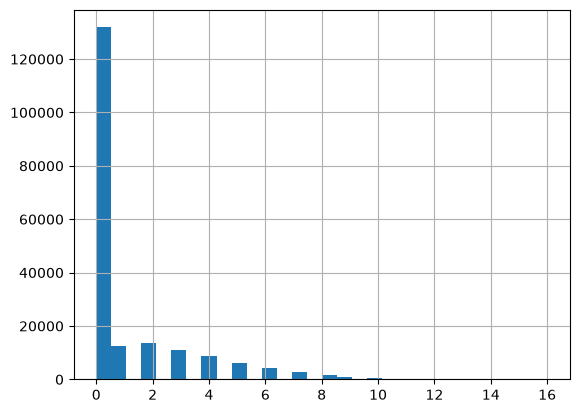

In [49]:
display(df_docs_out['n_skills'].describe(percentiles=[.1,.25,.5,.75,.9,.95]))
df_docs_out['n_skills'].hist(bins=30) # Diagramm

The distribution shows a right-skewed pattern: a few documents contain a very large number of skills, while the majority contain a moderate number. This pattern is to be expected in text mining of heterogeneous job data.

Comparison of Actual Skills vs. Target Skills by KldB Code:

In [50]:
# Skill column in Target
skill_col = None
for c in ["skill_id", "skill_uri", "skill", "skills"]:
    if c in df_soll_long_base.columns:
        skill_col = c
        break
assert skill_col is not None, f"Keine Skill-Spalte in df_soll_long_base gefunden. Spalten: {list(df_soll_long_base.columns)}"

# normalise skill_id 
if "skill_id" not in df_soll_long_base.columns:
    df_soll_long_base["skill_id"] = df_soll_long_base[skill_col].apply(to_skill_id)

# kldb_5_code as string
df_soll_long_base["kldb_5_code"] = df_soll_long_base["kldb_5_code"].astype(str).str.extract(r"(\d{5})")[0]
ext_new["kldb_5_code"] = ext_new["kldb_5_code"].astype(str).str.extract(r"(\d{5})")[0]

cmp = (ext_new.groupby("kldb_5_code")["skill_id"].nunique().to_frame("novel_skills").merge(
        df_soll_long_base.groupby("kldb_5_code")["skill_id"].nunique().to_frame("soll_skills"),left_index=True, right_index=True, how="left"
    )
)
cmp["ratio_novel_vs_soll"] = cmp["novel_skills"] / cmp["soll_skills"].replace(0, pd.NA)
display(cmp.sort_values("ratio_novel_vs_soll", ascending=False).head(15))

,novel_skills,soll_skills,ratio_novel_vs_soll
kldb_5_code,,,
72144,3031,136,22.286765
43313,896,54,16.592593
63301,685,57,12.017544
43343,1963,168,11.684524
43353,1766,197,8.964467
31114,763,116,6.577586
43333,231,49,4.714286
43413,1316,300,4.386667
27103,2504,595,4.208403


Qualification Check: Doc Frequency vs. Skill Count

In [51]:
display(ext_new[['skill_count','doc_freq']].describe(percentiles=[.1,.25,.5,.75,.9]))

,skill_count,doc_freq
count,22343.000000,22343.000000
mean,8.463277,8.182160
std,22.638060,20.348394
min,3.000000,3.000000
10%,3.000000,3.000000
25%,3.000000,3.000000
50%,3.000000,3.000000
75%,7.000000,7.000000
90%,15.000000,15.000000
max,874.000000,677.000000


Skills with a high document frequency and, at the same time, a high extraction frequency are strong candidates for profile enrichment.
Rare skills are deliberately not excluded, but may be interpreted as weaker signals.

Aggregated magnitude

In [52]:
print("Methodik 2.1")
print("Novel Skills gesamt:", ext_new['skill_id'].nunique())
print("Erweiterte KldB Codes:", ext_new['kldb_5_code'].nunique())

Methodik 2.1
Novel Skills gesamt: 7679
Erweiterte KldB Codes: 352


Skills by KLDB Code & Top Advanced Codes:

In [53]:
# Target skills per KldB (Baseline)
skill_col = None
for c in ["skill_id", "skill_uri", "skill", "skills"]:
    if c in df_soll_long_base.columns:
        skill_col = c
        break
assert skill_col is not None, "Skill-Spalte in df_soll_long_base"

base_counts = (
    df_soll_long_base.assign(kldb_5_code=lambda d: d["kldb_5_code"].astype(str).str.extract(r"(\d{5})")[0]).dropna(subset=["kldb_5_code", skill_col]).groupby("kldb_5_code")[skill_col].nunique()
    .rename("soll_skills").sort_values(ascending=False)
)

print("Top 10 KldB-Codes nach Anzahl SOLL-Skills:")
display(base_counts.head(10).to_frame())
print("\nVerteilung SOLL-Skills pro KldB-Code:")
display(base_counts.describe(percentiles=[.1,.25,.5,.75,.9,.95]).to_frame().T)


# Novel-Skills per KldB
novel_counts = (
    ext_new.assign(kldb_5_code=lambda d: d["kldb_5_code"].astype(str).str.extract(r"(\d{5})")[0]).dropna(subset=["kldb_5_code", "skill_id"]).groupby("kldb_5_code")["skill_id"].nunique()
    .rename("novel_skills").sort_values(ascending=False)
)

print("\nTop 10 KldB-Codes nach Anzahl NOVEL-Skills:")
display(novel_counts.head(10).to_frame())
print("\nVerteilung NOVEL-Skills pro KldB-Code:")
display(novel_counts.describe(percentiles=[.1,.25,.5,.75,.9,.95]).to_frame().T)
print("\nNovel Skills insgesamt (unique skill_id über alle Codes):", ext_new["skill_id"].nunique())
print("Novel Pairs insgesamt (KldB×Skill Zeilen):", len(ext_new))

Top 10 KldB-Codes nach Anzahl SOLL-Skills:


,soll_skills
kldb_5_code,
28194,1819
28294,1819
28394,1819
51534,1145
41414,1145
21124,1145
53134,1145
93604,1145
27224,1145



Verteilung SOLL-Skills pro KldB-Code:


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
soll_skills,1287.0,296.184149,242.218025,15.0,58.0,115.5,212.0,468.0,595.0,646.0,1819.0



Top 10 KldB-Codes nach Anzahl NOVEL-Skills:


,novel_skills
kldb_5_code,
72144,3031
27103,2504
43343,1963
43353,1766
43413,1316
43313,896
43414,871
31114,763
63301,685



Verteilung NOVEL-Skills pro KldB-Code:


,count,mean,std,min,10%,25%,50%,75%,90%,95%,max
novel_skills,352.0,63.474432,275.778792,1.0,1.0,2.0,6.0,20.0,72.8,198.85,3031.0



Novel Skills insgesamt (unique skill_id über alle Codes): 7679
Novel Pairs insgesamt (KldB×Skill Zeilen): 22343


On average, the KLDB codes being expanded are augmented by 64 skills (less than 1.1—there, approximately 170). The average is quite acceptable and still realistic. However, there are codes with the most extensive expansions, adding up to 3,037 new skills; a large portion of these will likely be general, irrelevant “noise.” (In the alternative NB-11 with stricter parameters, the average is 60 skills, and the maximum is 2,754 skills. This yields results similar to those in this notebook, but with stricter criteria and thus less noise—though, conversely, fewer KLDB codes are expanded.)

Although the skills in the experiment without resume are more precise than those here (only 36 new skills on average there), they may still contain noise and generic skills. However, using resume skills would map more useful new skills. Consequently, an approach using resume skills is considered more sensible overall. For this reason, NB11 with resume and moderate parameters continues to be used as the main variant.

Compared to the taxonomy-based methodology (10b), the text mining-based approach extracts fewer but more specific skills. This confirms the trade-off between recall and precision.

Double-check each code example. If `ext_new` is really supposed to be `novel vs`, then there should be no overlap, they must all be unique:

In [54]:
example_code = ext_new["kldb_5_code"].value_counts().index[0]

novel_set = set(ext_new.loc[ext_new["kldb_5_code"]==example_code, "skill_id"].dropna().astype(str))
soll_set  = set(df_soll_long_base.loc[df_soll_long_base["kldb_5_code"]==example_code, "skill_id"].dropna().astype(str))

inter = novel_set & soll_set
print("Example code:", example_code)
print("novel unique:", len(novel_set), "soll unique:", len(soll_set), "intersection:", len(inter))

Example code: 72144
novel unique: 3031 soll unique: 136 intersection: 0


Sample output, complete KLDB code 28213 (Fashion Design Occupations), target base profile + extension:

In [55]:
def show_profile_long_extended_2_1(kldb_code: str, n_base=30, n_ext=30):
    kldb_code = str(kldb_code).zfill(5)

    # Path Output
    SOLL_LONG_EXT_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "kldb_skills_soll_long_extended_2_1.parquet"
    df = pd.read_parquet(SOLL_LONG_EXT_PATH)

    # normalise Code/Skill 
    df["kldb_5_code"] = df["kldb_5_code"].astype(str).str.extract(r"(\d{5})")[0].str.zfill(5)
    if "skill_id" not in df.columns and "skill_uri" in df.columns:
        df["skill_id"] = df["skill_uri"].apply(to_skill_id)
    else:
        df["skill_id"] = df["skill_id"].apply(to_skill_id)

    # Soll (Target)
    base_keep = [c for c in ["kldb_5_code","kldb_title_de","kldb_title_en","skill_id","skill_title_en","relation_type","skill_type","reuse_level"] if c in df.columns]
    base_rows = (df[(df["kldb_5_code"] == kldb_code) & (df["is_extension"] == False)].loc[:, base_keep].drop_duplicates(subset=["kldb_5_code","skill_id"]).head(n_base))

    # Expansion
    ext_keep = [c for c in ["kldb_5_code","skill_id","doc_freq","skill_count","example_label","example_source","example_lang","extension_method"] if c in df.columns]
    ext_rows = (df[(df["kldb_5_code"] == kldb_code) & (df["is_extension"] == True)].loc[:, ext_keep].drop_duplicates(subset=["kldb_5_code","skill_id"]))

    # As in 10b: Sort by doc_freq/skill_count
    sort_cols = [c for c in ["doc_freq","skill_count"] if c in ext_rows.columns]
    if sort_cols:
        ext_rows = ext_rows.sort_values(sort_cols, ascending=False)
    ext_rows = ext_rows.head(n_ext)

    # Counts
    base_n = df[(df["kldb_5_code"] == kldb_code) & (df["is_extension"] == False)]["skill_id"].nunique()
    ext_n  = df[(df["kldb_5_code"] == kldb_code) & (df["is_extension"] == True)]["skill_id"].nunique()
    print("KldB:", kldb_code)
    print("Base skills (unique):", base_n)
    print("Extension skills (unique):", ext_n)
    print("="*60)
    print("BASE (sample)")
    display(base_rows)
    print("EXTENSION (sample)")
    display(ext_rows)

show_profile_long_extended_2_1("28213", n_base=10, n_ext=10) # Sample code

KldB: 28213
Base skills (unique): 356
Extension skills (unique): 2
BASE (sample)


,kldb_5_code,kldb_title_de,kldb_title_en,skill_id,skill_title_en,relation_type,skill_type,reuse_level
229989,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/0cf4c414...,footwear and leather goods marketing planning,essential,knowledge,sector-specific
229990,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/a4cfad38...,footwear materials,essential,knowledge,sector-specific
229991,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/c6846331...,footwear manufacturing technology,essential,knowledge,sector-specific
229992,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/de278695...,footwear creation process,essential,knowledge,sector-specific
229993,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/e54a3ed7...,footwear quality,essential,knowledge,sector-specific
229994,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/e6b31fc5...,ergonomics in footwear and leather goods design,essential,knowledge,sector-specific
229995,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/ec7fd241...,footwear components,essential,knowledge,sector-specific
229996,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/f3880260...,last types,essential,knowledge,sector-specific
229997,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/10311d30...,create patterns for footwear,essential,skill/competence,sector-specific
229998,28213,Berufe im Modedesign - komplexe Spezialistentä...,Occupations in fashion design-complex tasks,ESCO:http://data.europa.eu/esco/skill/11a76a95...,innovate in footwear and leather goods industry,essential,skill/competence,cross-sector


EXTENSION (sample)


,kldb_5_code,skill_id,doc_freq,skill_count,example_label,extension_method
813509,28213,RESUME:ant,5.0,5.0,Ant,method_2_1_text_mining
813510,28213,RESUME:daily scrum meetings,3.0,3.0,Daily scrum meetings,method_2_1_text_mining


The reason for these short noise tokens is that TF-IDF initially extracts only statistically significant terms (not actual skills), and this results in a set of less stable candidates (especially for skills derived from, for example, a smaller subset of the German dataset). In addition, preprocessing/formatting artifacts and string similarity mapping can lead to false positives and introduce noise.

Sample output, additional KLDB code 27103 (occupations in technical research and development, development engineer), target base profile + extension:

In [56]:
show_profile_long_extended_2_1("27103", n_base=10, n_ext=10) # sample code

KldB: 27103
Base skills (unique): 595
Extension skills (unique): 2504
BASE (sample)


,kldb_5_code,kldb_title_de,kldb_title_en,skill_id,skill_title_en,relation_type,skill_type,reuse_level
185939,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/41daf4d3...,properties of textile materials,essential,knowledge,sector-specific
185940,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/7cc80984...,textile technologies,essential,knowledge,cross-sector
185941,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/bc93e930...,braiding technology,essential,knowledge,sector-specific
185942,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/dbb0afa6...,textile printing technology,essential,knowledge,cross-sector
185943,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/09853c3b...,distinguish accessories,essential,skill/competence,sector-specific
185944,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/31dadcd2...,control textile process,essential,skill/competence,sector-specific
185945,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/434e926b...,measure yarn count,essential,skill/competence,sector-specific
185946,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/50ab7296...,maintain work standards,essential,skill/competence,cross-sector
185947,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/62879c0f...,use textile finishing machine technologies,essential,skill/competence,cross-sector
185948,27103,Berufe in der technischen Forschung und Entwic...,Occupations in technical research and developm...,ESCO:http://data.europa.eu/esco/skill/6af2d621...,test physical properties of textiles,essential,skill/competence,sector-specific


EXTENSION (sample)


,kldb_5_code,skill_id,doc_freq,skill_count,example_label,extension_method
812816,27103,RESUME:using,677.0,874.0,Using,method_2_1_text_mining
812053,27103,RESUME:mvc,651.0,711.0,MVC,method_2_1_text_mining
811711,27103,RESUME:hibernate,633.0,702.0,hibernate,method_2_1_text_mining
811818,27103,RESUME:j2ee,591.0,642.0,J2EE,method_2_1_text_mining
811894,27103,RESUME:jquery,585.0,655.0,jquery,method_2_1_text_mining
811490,27103,RESUME:developer,581.0,644.0,developer,method_2_1_text_mining
811672,27103,RESUME:git,578.0,683.0,GIT,method_2_1_text_mining
812266,27103,RESUME:python,577.0,682.0,PYTHON,method_2_1_text_mining
810531,27103,LINKEDIN:abi,567.0,576.0,ABI,method_2_1_text_mining
811903,27103,RESUME:jsp,438.0,519.0,JSP,method_2_1_text_mining


## 13. Gold/Eval Export (Similar to 10b)

Standard format for Notebook 08 evaluation, similar to 10b:
- doc_id
- skill_id
- method
- Metadata for traceability: (source_type, source_name, job_title_raw, kldb_5_code, match scores, ...)
- Output: pred_skills_2_1.parquet: doc_id, skill_id, method + metadata

In [57]:
PRED_PATH = PROJECT_ROOT / "data" / "processed_external" / "method_2_1" / "pred_skills_11_mining_21.parquet"

pred = doc_skills_long[["doc_id", "skill_id"]].dropna().drop_duplicates().copy()
pred["method"] = METHOD_NAME
meta_cols_pref = ["doc_id", "source_type", "source_name", "job_title_raw", "kldb_5_code", "kldb_match_score", "match_lang", "match_method"]
meta_cols = [c for c in meta_cols_pref if c in df_docs_run.columns]

pred = pred.merge(df_docs_run[meta_cols].drop_duplicates("doc_id"),on="doc_id",how="left")

pred.to_parquet(PRED_PATH, index=False) # Speichern
print("Saved:", PRED_PATH, "| rows:", len(pred), "| unique docs:", pred["doc_id"].nunique())
display(pred.head(10))

Saved: c:\Users\sigle\OneDrive - Hochschule Reutlingen\Dokumente\Profilerweiterung\data\processed_external\method_2_1\pred_skills_11_mining_21.parquet | rows: 213341 | unique docs: 62129


,doc_id,skill_id,method,source_type,source_name,job_title_raw,kldb_5_code,kldb_match_score,match_lang,match_method
0,921716,LINKEDIN:open houses,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Marketing Coordinator,92113,100.0,en,exact
1,1829192,RESUME:license,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Mental Health Therapist/Counselor,84184,90.0,en,fuzzy
2,35982263,LINKEDIN:sheet metal,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Service Technician,25132,100.0,en,exact
3,103254301,LINKEDIN:creative design,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Producer,94404,100.0,en,exact
4,103254301,ESCO:http://data.europa.eu/esco/skill/8afe68ff...,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Producer,94404,100.0,en,exact
5,103254301,RESUME:immersive experiences,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Producer,94404,100.0,en,exact
6,103254301,RESUME:create,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Producer,94404,100.0,en,exact
7,1218575,RESUME:register,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Respiratory Therapist,81733,100.0,en,exact
8,1218575,LINKEDIN:occupational therapy,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Respiratory Therapist,81733,100.0,en,exact
9,1218575,ESCO:http://data.europa.eu/esco/skill/e35bfbda...,method_2_1_text_mining,job_ad,kaggle_linkedin_2023_2024_big,Respiratory Therapist,81733,100.0,en,exact


# Conclusion: Notebook 11
In this notebook, the text-mining-based profile extension method (Methodology 2.1) was implemented. Based on external text sources, statistically significant terms were extracted using TF-IDF (N-grams) and mapped to established skill concepts via string similarity matching. Compared to the rule-based Method 1.1, this approach is more data-driven and exploratory in nature and is particularly well-suited for identifying novel, market-driven skills.

The central challenge lay in controlling noise while maintaining high scalability. Through targeted text cleaning, domain-specific stoplists, multi-stage frequency filters, and conservative matching parameters, a stable and traceable pipeline was implemented that runs reliably even during a full run.

The results show that:
- a large proportion of the documents yield at least one skill,
- in particular, technology- and tool-related skills are frequently newly identified,
- overall, the approach extracts fewer but more specific skills than the taxonomy-based method.

The clear separation of target skills and newly identified extension skills results in a consistent, expanded target profile for each KldB code. The results confirm the expected trade-off between precision and recall.

**Distinction from the alternative Notebooks 11:** The alternative test notebooks show that while stricter parameters enable more precise skill assignments, they still contain generic noise and simultaneously significantly reduce the expansion of the KLDB codes. Notebook 11 already represents a reasonable compromise between precision and coverage. By additionally using resume skills, more relevant new skills can be mapped without significantly compromising quality. Therefore, Notebook 11 with moderate parameters will continue to be used as the main variant.

In the following Notebook 12 for the ArchiMate demo, files (located under data/processed_archimate/) are created that contain the base profiles as well as extensions, thereby representing the overall result of the work/competency profile extension.